# 🌊 Underwater Image Enhancement — Zero-DCE + FUnIE-GAN (Unpaired: Sea-thru × UIEB)

Pipeline membandingkan **dua variasi** FUnIE-GAN:
- **Variasi A (Baseline):** Input = Sea-thru RAW, Referensi D = UIEB
- **Variasi B (Proposed):** Input = Zero-DCE(Sea-thru), Referensi D = Sea-thru Light-Corrected + UIEB


## 📦 1. Setup & Konfigurasi

In [1]:
import os, hashlib, warnings, glob, random, itertools, time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from PIL import Image, UnidentifiedImageError
from collections import defaultdict, Counter
from concurrent.futures import ThreadPoolExecutor, as_completed
from numpy.fft import fft2, ifft2

import cv2
from sklearn.model_selection import train_test_split
import albumentations as A

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.transforms.functional as TF
from torch.utils.data import Dataset, DataLoader, random_split

warnings.filterwarnings('ignore')
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'✅ Device  : {DEVICE}')
print(f'   PyTorch : {torch.__version__}')


✅ Device  : cuda
   PyTorch : 2.10.0+cu128


In [2]:
# ── PATH KONFIGURASI ─────────────────────────────────────────────
BASE_PATH        = '/kaggle/input/datasets/colorlabeilat/seathru-dataset'
UIEB_PATH        = '/kaggle/input/datasets/larjeck/uieb-dataset-reference'
DCE_WEIGHTS      = '/kaggle/input/models/cheryleugene/epoch99-pth/pytorch/default/1/Epoch99.pth'

RESIZE_OUTPUT        = '/kaggle/working/dataset_512'
EDA_OUTPUT           = '/kaggle/working/eda_output'
SPLIT_OUTPUT         = '/kaggle/working/dataset_split'
MODEL_OUTPUT         = '/kaggle/working/model_output'
CKPT_DIR             = '/kaggle/working/checkpoints'
DCE_CORRECTED_OUTPUT = '/kaggle/working/seathru_dce_corrected'   # Sea-thru hasil Zero-DCE

TARGET_SIZE   = (256, 256)
SUPPORTED_EXT = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.tif', '.webp'}

# ── Training ──
BATCH_SIZE    = 8
NUM_EPOCHS    = 5
LR_G          = 2e-4
LR_D          = 2e-4
BETA1         = 0.5
BETA2         = 0.999
LAMBDA_PERCEP = 10.0   # bobot perceptual (content-preservation) loss

# Sea-thru folders (domain input)
d1 = os.path.join(BASE_PATH, 'D1', 'D1', 'linearPNG')
d2 = os.path.join(BASE_PATH, 'D2', 'D2', 'linearPNG')
d3 = os.path.join(BASE_PATH, 'D3', 'D3', 'linearPNG')
d5 = os.path.join(BASE_PATH, 'D5', 'D5', 'linearPNG')
SPECIFIC_PATHS = [d1, d2, d3, d5]

for d in [RESIZE_OUTPUT, EDA_OUTPUT, SPLIT_OUTPUT, MODEL_OUTPUT, CKPT_DIR, DCE_CORRECTED_OUTPUT]:
    Path(d).mkdir(parents=True, exist_ok=True)

print('✅ Konfigurasi selesai')
print('   Sea-thru folders (input domain):')
for label, p in zip(['D1','D2','D3','D5'], SPECIFIC_PATHS):
    status = '✅' if Path(p).exists() else '❌ TIDAK ADA'
    print(f'   {label}: {status}')
status_uieb = '✅' if Path(UIEB_PATH).exists() else '❌ TIDAK ADA'
print(f'   UIEB reference (target domain): {status_uieb}')
print(f'      → {UIEB_PATH}')


✅ Konfigurasi selesai
   Sea-thru folders (input domain):
   D1: ✅
   D2: ✅
   D3: ✅
   D5: ✅
   UIEB reference (target domain): ✅
      → /kaggle/input/datasets/larjeck/uieb-dataset-reference


## 🛠️ 2. Fungsi Utilitas

In [3]:
def get_image_paths(folders=None):
    if isinstance(folders, str): folders = [folders]
    if folders is None: folders = SPECIFIC_PATHS
    all_paths = []
    for fp in folders:
        fp = Path(fp)
        if fp.exists():
            found = sorted([p for p in fp.rglob('*') if p.suffix.lower() in SUPPORTED_EXT])
            print(f'   [{fp.parent.name}/{fp.name}] {len(found)} file')
            all_paths.extend(found)
        else:
            print(f'   ⚠️  Tidak ada: {fp}')
    return all_paths

def safe_open(path):
    try:
        img = Image.open(path); img.verify()
        img = Image.open(path); img.load()
        return img, None
    except Exception as e:
        return None, str(e)

def file_md5(path):
    h = hashlib.md5()
    with open(path, 'rb') as f:
        for chunk in iter(lambda: f.read(8192), b''): h.update(chunk)
    return h.hexdigest()

def perceptual_hash(img, size=8):
    gray = img.convert('L').resize((size, size), Image.LANCZOS)
    arr  = np.array(gray, dtype=float)
    return ''.join('1' if px > arr.mean() else '0' for px in arr.flatten())

def hamming(h1, h2): return sum(a != b for a, b in zip(h1, h2))

def print_section(title):
    print(f"\n{'═'*60}\n  {title}\n{'═'*60}")

def savefig(name, out_dir=EDA_OUTPUT):
    out = Path(out_dir) / name
    plt.savefig(out, dpi=120, bbox_inches='tight')
    plt.show(); plt.close()
    print(f'   💾 {out}')

def resize_one(src, dst):
    try:
        Path(dst).parent.mkdir(parents=True, exist_ok=True)
        img = Image.open(src).convert('RGB').resize(TARGET_SIZE, Image.LANCZOS)
        ext = Path(src).suffix.lower()
        img.save(dst, format='JPEG' if ext in {'.jpg','.jpeg'} else 'PNG',
                 **({'quality':95} if ext in {'.jpg','.jpeg'} else {}))
        return ('ok', str(src), '')
    except Exception as e:
        return ('error', str(src), str(e))

print('✅ Utilitas siap')


✅ Utilitas siap


## 📐 3. Resize Dataset ke 256×256

In [5]:
def run_resize(input_folders=None, output_dir=RESIZE_OUTPUT, max_workers=4):
    print_section('RESIZE DATASET')
    all_paths = get_image_paths(input_folders)
    total = len(all_paths)
    if total == 0:
        print('❌ Tidak ada gambar ditemukan.'); return []

    print(f'   Total  : {total} gambar → {TARGET_SIZE[0]}×{TARGET_SIZE[1]}')
    print(f'   Output : {output_dir}\n')

    pairs = []
    for src in all_paths:
        folder_label = src.parts[-3] if len(src.parts) >= 3 else 'img'
        dst = Path(output_dir) / f'{folder_label}_{src.name}'
        pairs.append((src, dst))

    success, errors = 0, []
    with ThreadPoolExecutor(max_workers=max_workers) as ex:
        futures = {ex.submit(resize_one, s, d): s for s, d in pairs}
        for i, f in enumerate(as_completed(futures), 1):
            st, p, msg = f.result()
            if st == 'ok': success += 1
            else: errors.append((p, msg))
            if i % 100 == 0 or i == total:
                print(f'   [{i}/{total}] {i/total*100:.0f}%', end='\r')

    print(f'\n   ✅ Berhasil : {success}  |  ❌ Gagal : {len(errors)}')
    return sorted([p for p in Path(output_dir).rglob('*') if p.suffix.lower() in SUPPORTED_EXT])

resized_paths = run_resize()
print(f'\n✅ {len(resized_paths)} gambar siap di {RESIZE_OUTPUT}')



════════════════════════════════════════════════════════════
  RESIZE DATASET
════════════════════════════════════════════════════════════
   [D1/linearPNG] 633 file
   [D2/linearPNG] 319 file
   [D3/linearPNG] 68 file
   [D5/linearPNG] 43 file
   Total  : 1063 gambar → 256×256
   Output : /kaggle/working/dataset_512

   [1063/1063] 100%
   ✅ Berhasil : 1063  |  ❌ Gagal : 0

✅ 1063 gambar siap di /kaggle/working/dataset_512


## 🔍 4. EDA (Exploratory Data Analysis)


🔍 Menjalankan EDA...

════════════════════════════════════════════════════════════
  4a. UKURAN GAMBAR
════════════════════════════════════════════════════════════
  OK:1063  Corrupt:0  Resolusi unik:1
  Width  min=256  max=256  mean=256
  Height min=256  max=256  mean=256
  Top 5:
         256x256 → 1063


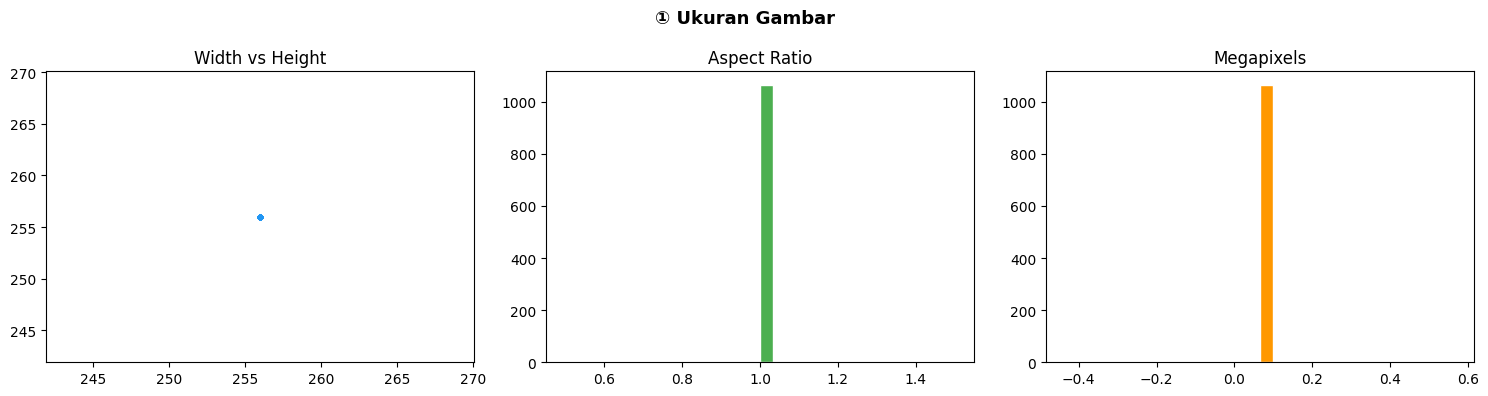

   💾 /kaggle/working/eda_output/1_image_sizes.png

════════════════════════════════════════════════════════════
  4b. DISTRIBUSI BRIGHTNESS
════════════════════════════════════════════════════════════
  Brightness min=7.4  max=41.5  avg=17.1
  Sangat gelap(<30): 1012 (95.2%)
  Gelap(30-80): 51 (4.8%)
  Normal(80-180): 0 (0.0%)
  Terang(>=180): 0 (0.0%)


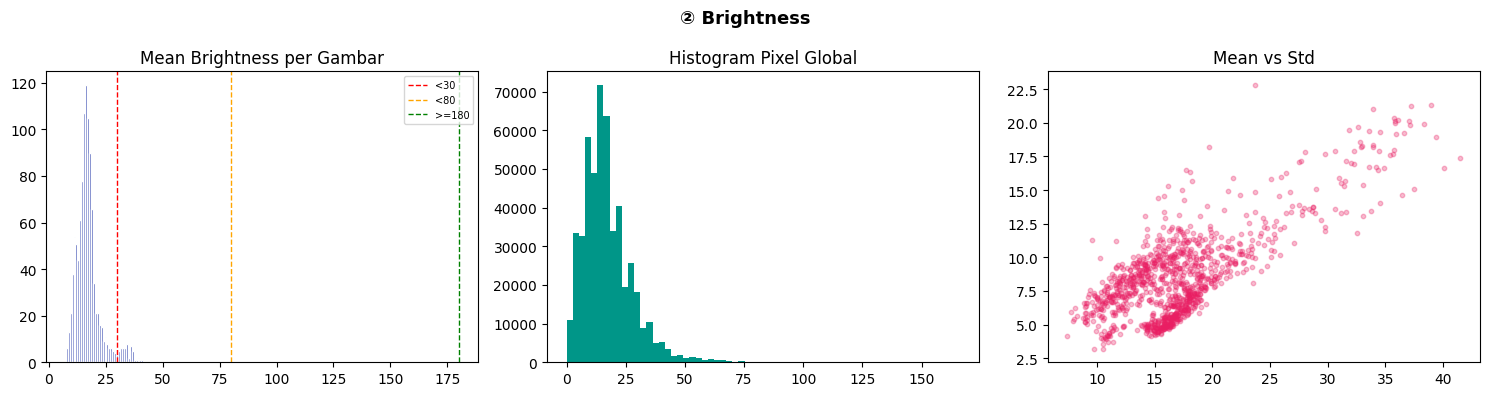

   💾 /kaggle/working/eda_output/2_brightness.png

════════════════════════════════════════════════════════════
  4c. FORMAT FILE
════════════════════════════════════════════════════════════
  Ekstensi: {'.png': 1063}
  Mode    : {'RGB': 1063}
  Ukuran  min=44.7KB  max=106.3KB  mean=77.9KB
  Corrupt : 0


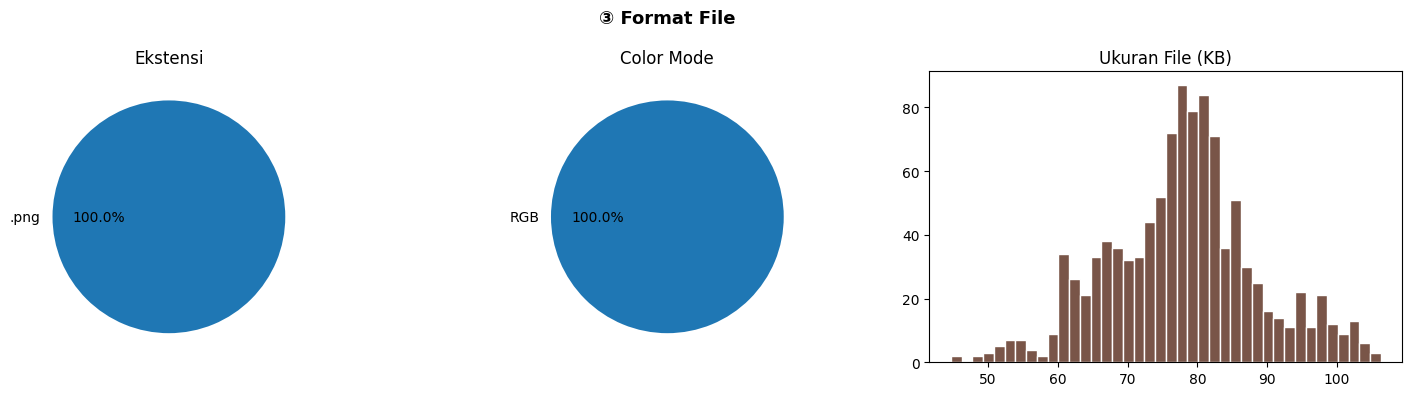

   💾 /kaggle/working/eda_output/3_file_formats.png

════════════════════════════════════════════════════════════
  4d. DETEKSI DUPLIKAT
════════════════════════════════════════════════════════════
  Menghitung MD5 & pHash...
    [1000/1063]
  Near-duplicate (pHash)...
  Exact: 0  Near: 114  Total bisa dibuang: 114


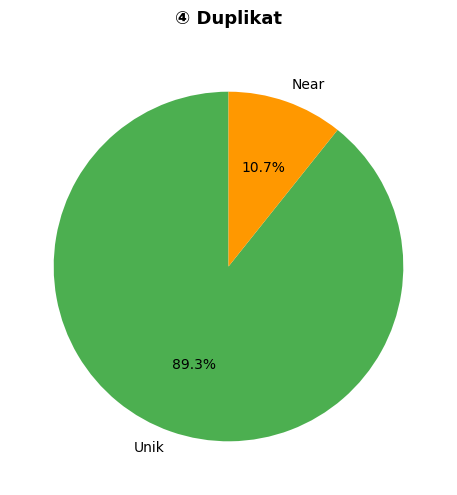

   💾 /kaggle/working/eda_output/4_duplicates.png

════════════════════════════════════════════════════════════
  4e. COLOR CHANNEL
════════════════════════════════════════════════════════════
  Mean  R=3.53  G=24.12  B=16.86
  G dominan: 1063 (100.0%)
  R/G ratio=0.147  ⚠️ color cast
  R/B ratio=0.212  ⚠️ color cast


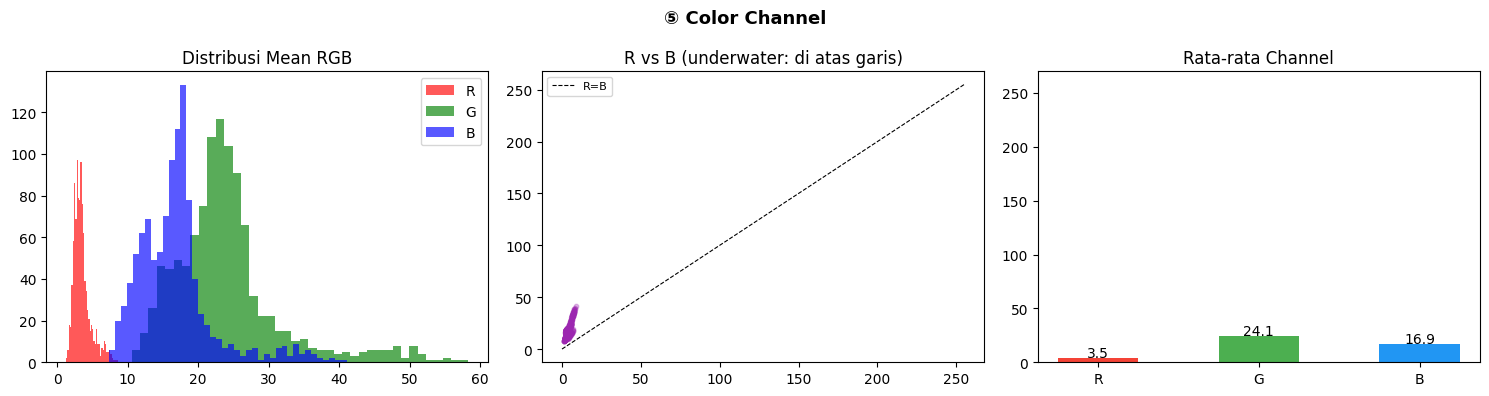

   💾 /kaggle/working/eda_output/5_color_channels.png

════════════════════════════════════════════════════════════
  4f. NOISE LEVEL
════════════════════════════════════════════════════════════
  Laplacian mean=116.9  Sigma mean=2.00  SNR mean=21.8dB
  Noise rendah:1063  sedang:0  tinggi:0


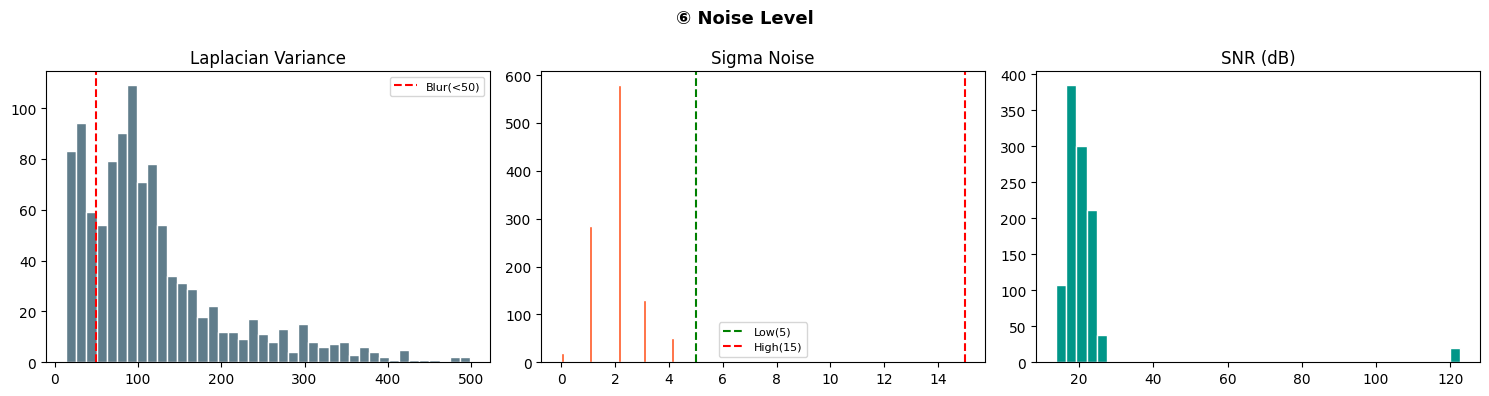

   💾 /kaggle/working/eda_output/6_noise.png

════════════════════════════════════════════════════════════
  RINGKASAN EDA
════════════════════════════════════════════════════════════
  Total gambar     : 1063
  Corrupt          : 0
  Duplikat exact   : 0
  Near-duplicate   : 114
  Sangat gelap     : 1012
  Noise tinggi     : 0
  Avg R/G ratio    : 0.147  ⚠️ color cast
  Estimasi dibuang : 1126
  Estimasi siap    : -63


In [6]:
# ── 4a. Ukuran Gambar ────────────────────────────────────────────
def check_image_sizes(paths):
    print_section('4a. UKURAN GAMBAR')
    rec, err = [], []
    for p in paths:
        img, e = safe_open(p)
        if img is None: err.append(p); continue
        w, h = img.size
        rec.append({'path':str(p),'width':w,'height':h,
                    'aspect':round(w/h,3),'megapixels':round(w*h/1e6,3),'mode':img.mode})
    widths  = [r['width']      for r in rec]
    heights = [r['height']     for r in rec]
    aspects = [r['aspect']     for r in rec]
    mps     = [r['megapixels'] for r in rec]
    res_ctr = Counter(f"{r['width']}x{r['height']}" for r in rec)
    print(f'  OK:{len(rec)}  Corrupt:{len(err)}  Resolusi unik:{len(res_ctr)}')
    print(f'  Width  min={min(widths)}  max={max(widths)}  mean={np.mean(widths):.0f}')
    print(f'  Height min={min(heights)}  max={max(heights)}  mean={np.mean(heights):.0f}')
    print('  Top 5:')
    for r, c in res_ctr.most_common(5): print(f'    {r:>12} → {c}')
    fig, axes = plt.subplots(1,3,figsize=(15,4))
    fig.suptitle('① Ukuran Gambar', fontsize=13, fontweight='bold')
    axes[0].scatter(widths,heights,alpha=0.4,s=10,color='#2196F3')
    axes[0].set_title('Width vs Height')
    axes[1].hist(aspects,bins=30,color='#4CAF50',edgecolor='white')
    axes[1].set_title('Aspect Ratio')
    axes[2].hist(mps,bins=30,color='#FF9800',edgecolor='white')
    axes[2].set_title('Megapixels')
    plt.tight_layout(); savefig('1_image_sizes.png')
    return {'records':rec,'errors':err}

# ── 4b. Brightness ───────────────────────────────────────────────
def check_brightness(paths):
    print_section('4b. DISTRIBUSI BRIGHTNESS')
    records, all_pixels = [], []
    for p in paths:
        img, e = safe_open(p)
        if img is None: continue
        gray = np.array(img.convert('L'), dtype=np.float32)
        all_pixels.append(gray.flatten())
        records.append({'path':str(p),'mean':float(gray.mean()),'std':float(gray.std()),
                        'dark_pct':float((gray<50).sum()/gray.size*100),
                        'bright_pct':float((gray>200).sum()/gray.size*100)})
    means = [r['mean'] for r in records]
    stds  = [r['std']  for r in records]
    cats  = {'Sangat gelap(<30)':sum(1 for m in means if m<30),
             'Gelap(30-80)':sum(1 for m in means if 30<=m<80),
             'Normal(80-180)':sum(1 for m in means if 80<=m<180),
             'Terang(>=180)':sum(1 for m in means if m>=180)}
    print(f'  Brightness min={min(means):.1f}  max={max(means):.1f}  avg={np.mean(means):.1f}')
    for k,v in cats.items(): print(f'  {k}: {v} ({v/len(records)*100:.1f}%)')
    ap = np.concatenate(all_pixels) if all_pixels else np.array([])
    fig, axes = plt.subplots(1,3,figsize=(15,4))
    fig.suptitle('② Brightness', fontsize=13, fontweight='bold')
    axes[0].hist(means,bins=40,color='#3F51B5',edgecolor='white')
    for v,c,l in [(30,'red','<30'),(80,'orange','<80'),(180,'green','>=180')]:
        axes[0].axvline(v,color=c,linestyle='--',linewidth=1,label=l)
    axes[0].set_title('Mean Brightness per Gambar'); axes[0].legend(fontsize=7)
    if len(ap)>0:
        axes[1].hist(ap[::max(1,len(ap)//500_000)],bins=64,color='#009688')
        axes[1].set_title('Histogram Pixel Global')
    axes[2].scatter(means,stds,alpha=0.3,s=10,color='#E91E63')
    axes[2].set_title('Mean vs Std')
    plt.tight_layout(); savefig('2_brightness.png')
    return {'records':records,'all_pixels':ap}

# ── 4c. Format File ──────────────────────────────────────────────
def check_file_formats(paths):
    print_section('4c. FORMAT FILE')
    ext_ctr, mode_ctr, sizes, corrupt = Counter(), Counter(), [], []
    for p in paths:
        p = Path(p); ext = p.suffix.lower()
        ext_ctr[ext] += 1; sizes.append(p.stat().st_size/1024)
        img, e = safe_open(p)
        if img is None: corrupt.append(p); continue
        mode_ctr[img.mode] += 1
    print(f'  Ekstensi: {dict(ext_ctr.most_common())}')
    print(f'  Mode    : {dict(mode_ctr.most_common())}')
    print(f'  Ukuran  min={min(sizes):.1f}KB  max={max(sizes):.1f}KB  mean={np.mean(sizes):.1f}KB')
    print(f'  Corrupt : {len(corrupt)}')
    fig, axes = plt.subplots(1,3,figsize=(15,4))
    fig.suptitle('③ Format File', fontsize=13, fontweight='bold')
    axes[0].pie(list(ext_ctr.values()),labels=list(ext_ctr.keys()),autopct='%1.1f%%')
    axes[0].set_title('Ekstensi')
    if mode_ctr:
        axes[1].pie(list(mode_ctr.values()),labels=list(mode_ctr.keys()),autopct='%1.1f%%')
    axes[1].set_title('Color Mode')
    axes[2].hist(sizes,bins=40,color='#795548',edgecolor='white')
    axes[2].set_title('Ukuran File (KB)')
    plt.tight_layout(); savefig('3_file_formats.png')
    return {'ext_counter':ext_ctr,'mode_counter':mode_ctr,'size_kb':sizes,'corrupt':corrupt}

# ── 4d. Duplikat ─────────────────────────────────────────────────
def detect_duplicates(paths):
    print_section('4d. DETEKSI DUPLIKAT')
    md5_map, phash_map, exact_dups, near_dups = defaultdict(list), [], [], []
    print('  Menghitung MD5 & pHash...')
    for i, p in enumerate(paths):
        if (i+1)%100==0: print(f'    [{i+1}/{len(paths)}]',end='\r')
        img, e = safe_open(p)
        if img is None: continue
        md5_map[file_md5(p)].append(str(p))
        phash_map.append((str(p), perceptual_hash(img)))
    for md5, ps in md5_map.items():
        if len(ps)>1: exact_dups.append({'hash':md5,'files':ps})
    print('\n  Near-duplicate (pHash)...')
    visited = set()
    for i in range(len(phash_map)):
        if phash_map[i][0] in visited: continue
        group = [phash_map[i][0]]
        for j in range(i+1, len(phash_map)):
            if phash_map[j][0] not in visited and hamming(phash_map[i][1],phash_map[j][1])<=5:
                group.append(phash_map[j][0]); visited.add(phash_map[j][0])
        if len(group)>1: near_dups.append(group)
    te = sum(len(g['files'])-1 for g in exact_dups)
    tn = sum(len(g)-1 for g in near_dups)
    print(f'  Exact: {te}  Near: {tn}  Total bisa dibuang: {te+tn}')
    total = len(paths); clean = total-te-tn
    filtered = [(l,v,c) for l,v,c in zip(['Unik','Exact','Near'],[clean,te,tn],['#4CAF50','#F44336','#FF9800']) if v>0]
    if filtered:
        fl,fv,fc = zip(*filtered)
        fig, ax = plt.subplots(figsize=(5,5))
        ax.pie(fv,labels=fl,autopct='%1.1f%%',colors=fc,startangle=90)
        fig.suptitle('④ Duplikat',fontsize=13,fontweight='bold')
        plt.tight_layout(); savefig('4_duplicates.png')
    return {'exact_duplicates':exact_dups,'near_duplicates':near_dups}

# ── 4e. Color Channel ────────────────────────────────────────────
def analyze_color_channels(paths):
    print_section('4e. COLOR CHANNEL')
    records, all_r, all_g, all_b = [], [], [], []
    for p in paths:
        img, e = safe_open(p)
        if img is None: continue
        arr = np.array(img.convert('RGB'), dtype=np.float32)
        rm,gm,bm = arr[:,:,0].mean(), arr[:,:,1].mean(), arr[:,:,2].mean()
        all_r.append(rm); all_g.append(gm); all_b.append(bm)
        records.append({'path':str(p),'r_mean':float(rm),'g_mean':float(gm),'b_mean':float(bm),
                        'dominant':['R','G','B'][np.argmax([rm,gm,bm])],
                        'rg_ratio':float(rm/(gm+1e-5)),'rb_ratio':float(rm/(bm+1e-5))})
    dom = Counter(r['dominant'] for r in records)
    rg  = np.mean([r['rg_ratio'] for r in records])
    rb  = np.mean([r['rb_ratio'] for r in records])
    print(f'  Mean  R={np.mean(all_r):.2f}  G={np.mean(all_g):.2f}  B={np.mean(all_b):.2f}')
    for ch,cnt in dom.most_common(): print(f'  {ch} dominan: {cnt} ({cnt/len(records)*100:.1f}%)')
    print(f'  R/G ratio={rg:.3f}  {"⚠️ color cast" if rg<0.8 else "✅"}')
    print(f'  R/B ratio={rb:.3f}  {"⚠️ color cast" if rb<0.6 else "✅"}')
    fig, axes = plt.subplots(1,3,figsize=(15,4))
    fig.suptitle('⑤ Color Channel',fontsize=13,fontweight='bold')
    axes[0].hist(all_r,bins=40,alpha=0.65,color='red',label='R')
    axes[0].hist(all_g,bins=40,alpha=0.65,color='green',label='G')
    axes[0].hist(all_b,bins=40,alpha=0.65,color='blue',label='B')
    axes[0].set_title('Distribusi Mean RGB'); axes[0].legend()
    axes[1].scatter(all_r,all_b,alpha=0.3,s=10,color='#9C27B0')
    axes[1].plot([0,255],[0,255],'k--',linewidth=0.8,label='R=B')
    axes[1].set_title('R vs B (underwater: di atas garis)'); axes[1].legend(fontsize=8)
    mrg = [np.mean(all_r),np.mean(all_g),np.mean(all_b)]
    bars = axes[2].bar(['R','G','B'],mrg,color=['#F44336','#4CAF50','#2196F3'],width=0.5)
    for bar,val in zip(bars,mrg):
        axes[2].text(bar.get_x()+bar.get_width()/2,bar.get_height()+1,f'{val:.1f}',ha='center')
    axes[2].set_title('Rata-rata Channel'); axes[2].set_ylim(0,270)
    plt.tight_layout(); savefig('5_color_channels.png')
    return {'records':records,'all_r':all_r,'all_g':all_g,'all_b':all_b}

# ── 4f. Noise Level ──────────────────────────────────────────────
def estimate_noise(paths):
    print_section('4f. NOISE LEVEL')
    records = []
    for p in paths:
        img, e = safe_open(p)
        if img is None: continue
        gray = np.array(img.convert('L'), dtype=np.float64)
        h, w = gray.shape
        kx = np.array([[0,1,0],[1,-4,1],[0,1,0]], dtype=np.float64)
        pad_k = np.zeros((h,w)); pad_k[:3,:3] = kx
        lap_var = float(np.var(np.real(ifft2(fft2(gray)*fft2(pad_k)))))
        diff = np.concatenate([np.diff(gray,axis=0).flatten(),np.diff(gray,axis=1).flatten()])
        sigma = float(np.sqrt(0.5)*np.median(np.abs(diff))/0.6745)
        snr   = float(10*np.log10(np.mean(gray**2)/(sigma**2+1e-10)))
        records.append({'path':str(p),'lap_var':lap_var,'sigma_noise':sigma,'snr_db':snr})
    lap_vars = [r['lap_var']     for r in records]
    sigmas   = [r['sigma_noise'] for r in records]
    snrs     = [r['snr_db']      for r in records]
    print(f'  Laplacian mean={np.mean(lap_vars):.1f}  Sigma mean={np.mean(sigmas):.2f}  SNR mean={np.mean(snrs):.1f}dB')
    low  = sum(1 for s in sigmas if s<5)
    med  = sum(1 for s in sigmas if 5<=s<15)
    high = sum(1 for s in sigmas if s>=15)
    print(f'  Noise rendah:{low}  sedang:{med}  tinggi:{high}')
    if np.mean(sigmas)>10: print('  ⚠️  Noise TINGGI — pertimbangkan denoising')
    if np.mean(lap_vars)<100: print('  ⚠️  Sharpness RENDAH — banyak blur')
    fig, axes = plt.subplots(1,3,figsize=(15,4))
    fig.suptitle('⑥ Noise Level',fontsize=13,fontweight='bold')
    axes[0].hist(lap_vars,bins=40,color='#607D8B',edgecolor='white')
    axes[0].axvline(50,color='red',linestyle='--',label='Blur(<50)'); axes[0].legend(fontsize=8)
    axes[0].set_title('Laplacian Variance')
    axes[1].hist(sigmas,bins=40,color='#FF5722',edgecolor='white')
    axes[1].axvline(5,color='green',linestyle='--',label='Low(5)')
    axes[1].axvline(15,color='red',linestyle='--',label='High(15)'); axes[1].legend(fontsize=8)
    axes[1].set_title('Sigma Noise')
    axes[2].hist(snrs,bins=40,color='#009688',edgecolor='white'); axes[2].set_title('SNR (dB)')
    plt.tight_layout(); savefig('6_noise.png')
    return {'records':records}

# ── Run semua EDA ─────────────────────────────────────────────────
print('\n🔍 Menjalankan EDA...')
size_r       = check_image_sizes(resized_paths)
brightness_r = check_brightness(resized_paths)
fmt_r        = check_file_formats(resized_paths)
dup_r        = detect_duplicates(resized_paths)
color_r      = analyze_color_channels(resized_paths)
noise_r      = estimate_noise(resized_paths)

# ── Ringkasan ─────────────────────────────────────────────────────
print_section('RINGKASAN EDA')
means     = [r['mean'] for r in brightness_r['records']]
very_dark = sum(1 for m in means if m<30)
corrupt   = len(fmt_r['corrupt'])
exact_dup = sum(len(g['files'])-1 for g in dup_r['exact_duplicates'])
near_dup  = sum(len(g)-1 for g in dup_r['near_duplicates'])
sigmas    = [r['sigma_noise'] for r in noise_r['records']]
rg        = [r['rg_ratio'] for r in color_r['records']]
buang     = corrupt + exact_dup + near_dup + very_dark
print(f'  Total gambar     : {len(resized_paths)}')
print(f'  Corrupt          : {corrupt}')
print(f'  Duplikat exact   : {exact_dup}')
print(f'  Near-duplicate   : {near_dup}')
print(f'  Sangat gelap     : {very_dark}')
print(f'  Noise tinggi     : {sum(1 for s in sigmas if s>=15)}')
print(f'  Avg R/G ratio    : {np.mean(rg):.3f}  {"⚠️ color cast" if np.mean(rg)<0.8 else "✅"}')
print(f'  Estimasi dibuang : {buang}')
print(f'  Estimasi siap    : {len(resized_paths)-buang}')


## 🧹 5. Data Cleaning

In [7]:
def calculate_laplacian_variance(gray_array):
    kx = np.array([[0,1,0],[1,-4,1],[0,1,0]], dtype=np.float64)
    h, w = gray_array.shape
    pad_k = np.zeros((h,w)); pad_k[:3,:3] = kx
    return float(np.var(np.real(ifft2(fft2(gray_array)*fft2(pad_k)))))

def execute_data_cleaning(dataset_dir, blur_threshold=15.0):
    dataset_path = Path(dataset_dir)
    if not dataset_path.exists():
        print(f'❌ Folder tidak ditemukan: {dataset_dir}'); return

    all_files = sorted([p for p in dataset_path.rglob('*') if p.is_file()])
    print_section('DATA CLEANING')
    print(f'  Total file awal  : {len(all_files)}')
    print(f'  Blur threshold   : {blur_threshold}')

    phash_map, lap_variances, to_delete = [], {}, set()

    print('\n  Scanning & kalkulasi metrik...')
    for i, path in enumerate(all_files):
        if (i+1)%100==0: print(f'    [{i+1}/{len(all_files)}]', end='\r')
        img, e = safe_open(path)
        if img is None: to_delete.add(path); continue
        gray = img.convert('L')
        arr  = np.array(gray.resize((8,8), Image.LANCZOS), dtype=float)
        phash = ''.join('1' if px>arr.mean() else '0' for px in arr.flatten())
        phash_map.append((path, phash))
        lap_variances[path] = calculate_laplacian_variance(np.array(gray, dtype=np.float64))

    print('\n  Identifikasi duplikat...')
    visited, dup_count = set(), 0
    for i in range(len(phash_map)):
        pi, hi = phash_map[i]
        if pi in visited: continue
        for j in range(i+1, len(phash_map)):
            pj, hj = phash_map[j]
            if pj not in visited and sum(a!=b for a,b in zip(hi,hj))<=5:
                to_delete.add(pj); visited.add(pj); dup_count += 1
        visited.add(pi)

    blur_count = sum(1 for p,v in lap_variances.items() if v<blur_threshold and p not in to_delete
                     and not to_delete.add(p))

    print(f'  Menghapus {len(to_delete)} gambar...')
    deleted = 0
    for p in to_delete:
        try: p.unlink(); deleted += 1
        except: pass

    print(f'\n  ✅ Duplikat dihapus : {dup_count}')
    print(f'  ✅ Blur dihapus     : {blur_count}')
    print(f'  ✅ Total dihapus    : {deleted}')
    print(f'  ✅ Sisa gambar      : {len(all_files)-deleted}')

execute_data_cleaning(RESIZE_OUTPUT, blur_threshold=15.0)



════════════════════════════════════════════════════════════
  DATA CLEANING
════════════════════════════════════════════════════════════
  Total file awal  : 1063
  Blur threshold   : 15.0

  Scanning & kalkulasi metrik...
    [1000/1063]
  Identifikasi duplikat...
  Menghapus 116 gambar...

  ✅ Duplikat dihapus : 114
  ✅ Blur dihapus     : 2
  ✅ Total dihapus    : 116
  ✅ Sisa gambar      : 947


## ⚙️ 6. Data Preprocessing

In [8]:
import albumentations as A

# Augmentation transform — tanpa split dataset
aug_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.RandomRotate90(p=0.4),
    A.RandomBrightnessContrast(brightness_limit=0.1, contrast_limit=0.1, p=0.3),
])

def execute_preprocessing(cleaned_dir=RESIZE_OUTPUT):
    print_section('DATA PREPROCESSING')
    input_path = Path(cleaned_dir)
    all_files  = sorted([p for p in input_path.rglob('*')
                         if p.suffix.lower() in SUPPORTED_EXT])
    if not all_files:
        print('❌ Tidak ada file.'); return []
    print(f'  Total file (no split): {len(all_files)}')
    return all_files

all_files = execute_preprocessing()
print(f'✅ {len(all_files)} gambar siap untuk training')



════════════════════════════════════════════════════════════
  DATA PREPROCESSING
════════════════════════════════════════════════════════════
  Total file (no split): 947
✅ 947 gambar siap untuk training


## 🧠 7. Dataset & Arsitektur Model

In [9]:
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

class ImageDataset(Dataset):
    """Dataset gambar generik → tensor [-1,1]. Dipakai untuk Sea-thru maupun referensi (UIEB / gabungan)."""
    def __init__(self, paths, size=(256, 256)):
        self.paths = sorted([str(p) for p in paths])
        self.tf = T.Compose([
            T.Resize(size),
            T.ToTensor(),
            T.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])   # → [-1, 1]
        ])
    def __len__(self):
        return len(self.paths)
    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGB')
        return self.tf(img)

# alias kompatibilitas dgn cell lama
SeaThruDataset = ImageDataset

# ── Path Sea-thru (domain input) ───────────────────────────────────
print('Sea-thru (input domain):')
seathru_paths = get_image_paths(SPECIFIC_PATHS)
print(f'✅ Sea-thru: {len(seathru_paths)} gambar\n')

# ── Path UIEB reference (domain target) ────────────────────────────
print('UIEB reference (target domain):')
uieb_paths = get_image_paths([UIEB_PATH])
print(f'✅ UIEB: {len(uieb_paths)} gambar')

# DataLoader Sea-thru (input untuk Generator)
seathru_ds     = ImageDataset(seathru_paths)
seathru_loader = DataLoader(seathru_ds, batch_size=BATCH_SIZE, shuffle=True,
                            num_workers=2, pin_memory=True, drop_last=True)
print(f'\n   Sea-thru batches : {len(seathru_loader)}')


Sea-thru (input domain):
   [D1/linearPNG] 633 file
   [D2/linearPNG] 319 file
   [D3/linearPNG] 68 file
   [D5/linearPNG] 43 file
✅ Sea-thru: 1063 gambar

UIEB reference (target domain):
   [larjeck/uieb-dataset-reference] 890 file
✅ UIEB: 890 gambar

   Sea-thru batches : 132


In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# ── Generator: U-Net style (FUnIE-GAN) ──
class EncBlock(nn.Module):
    def __init__(self, in_ch, out_ch, normalize=True):
        super().__init__()
        layers = [nn.Conv2d(in_ch, out_ch, 4, stride=2, padding=1, bias=not normalize)]
        if normalize:
            layers.append(nn.BatchNorm2d(out_ch))
        layers.append(nn.LeakyReLU(0.2, inplace=True))
        self.block = nn.Sequential(*layers)
    def forward(self, x):
        return self.block(x)


class DecBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=False):
        super().__init__()
        layers = [
            nn.ConvTranspose2d(in_ch, out_ch, 4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        ]
        if dropout:
            layers.append(nn.Dropout(0.5))
        self.block = nn.Sequential(*layers)
    def forward(self, x):
        return self.block(x)


class FUnIEGenerator(nn.Module):
    def __init__(self, in_ch=3, out_ch=3):
        super().__init__()
        self.enc1 = EncBlock(in_ch, 32,  normalize=False)
        self.enc2 = EncBlock(32,   128)
        self.enc3 = EncBlock(128,  256)
        self.enc4 = EncBlock(256,  256)
        self.enc5 = EncBlock(256,  256)
        self.dec5 = DecBlock(256,     256, dropout=True)
        self.dec4 = DecBlock(256+256, 256, dropout=True)
        self.dec3 = DecBlock(256+256, 128)
        self.dec2 = DecBlock(128+128,  64)
        self.dec1 = DecBlock(64+32,    32)
        self.out_conv = nn.Sequential(nn.Conv2d(32, out_ch, 1), nn.Tanh())
    def forward(self, x):
        e1 = self.enc1(x); e2 = self.enc2(e1); e3 = self.enc3(e2)
        e4 = self.enc4(e3); e5 = self.enc5(e4)
        d5 = self.dec5(e5)
        d4 = self.dec4(torch.cat([d5, e4], 1))
        d3 = self.dec3(torch.cat([d4, e3], 1))
        d2 = self.dec2(torch.cat([d3, e2], 1))
        d1 = self.dec1(torch.cat([d2, e1], 1))
        return self.out_conv(d1)


class FUnIEDiscriminator(nn.Module):
    """
    PatchGAN Discriminator — UNCONDITIONAL (setup unpaired).
    Karena Sea-thru (input) & UIEB (referensi) TIDAK berpasangan, D hanya menilai
    apakah sebuah gambar termasuk distribusi 'referensi nyata'.
    Input: gambar [B,3,256,256]  →  Output: patch map [B,1,16,16]
    """
    def __init__(self, in_ch=3):
        super().__init__()
        def block(ic, oc, stride=2, norm=True):
            layers = [nn.Conv2d(ic, oc, 4, stride=stride, padding=1, bias=not norm)]
            if norm:
                layers.append(nn.BatchNorm2d(oc))
            layers.append(nn.LeakyReLU(0.2, inplace=True))
            return nn.Sequential(*layers)
        self.model = nn.Sequential(
            block(in_ch, 32, stride=2, norm=False),
            block(32,    64, stride=2),
            block(64,   128, stride=2),
            block(128,  256, stride=2),
            nn.Conv2d(256, 1, kernel_size=3, stride=1, padding=1),
        )
    def forward(self, img):
        return self.model(img)


def build_models():
    """Buat pasangan Generator + Discriminator baru (fresh weights)."""
    return FUnIEGenerator().to(DEVICE), FUnIEDiscriminator().to(DEVICE)


# ── Sanity check ───────────────────────────────────────────────────
_G, _D = build_models()
_dummy = torch.randn(2, 3, 256, 256).to(DEVICE)
_outG  = _G(_dummy); _outD = _D(_outG)
print(f'Generator output shape    : {_outG.shape}')
print(f'Discriminator output shape: {_outD.shape}')
print(f'   Generator     : {sum(p.numel() for p in _G.parameters()):,} params')
print(f'   Discriminator : {sum(p.numel() for p in _D.parameters()):,} params')
del _G, _D, _dummy, _outG, _outD
print('\n✅ Arsitektur model siap (Discriminator unconditional / unpaired).')


Generator output shape    : torch.Size([2, 3, 256, 256])
Discriminator output shape: torch.Size([2, 1, 16, 16])
   Generator     : 7,197,507 params
   Discriminator : 692,897 params

✅ Arsitektur model siap (Discriminator unconditional / unpaired).


In [12]:
# ── Zero-DCE (DCENet) ─────────────────────────────────────────────
class DCENet(nn.Module):
    """
    Zero-DCE: Zero-Reference Deep Curve Estimation.
    Tidak butuh paired data atau ground truth.
    Memperbaiki brightness & low-light via curve estimation.
    Output: enhanced image [0,1] + 8 curve maps.
    """
    def __init__(self, number_f=32):
        super().__init__()
        self.relu    = nn.ReLU(inplace=True)
        self.e_conv1 = nn.Conv2d(3,          number_f, 3, 1, 1, bias=True)
        self.e_conv2 = nn.Conv2d(number_f,   number_f, 3, 1, 1, bias=True)
        self.e_conv3 = nn.Conv2d(number_f,   number_f, 3, 1, 1, bias=True)
        self.e_conv4 = nn.Conv2d(number_f,   number_f, 3, 1, 1, bias=True)
        self.e_conv5 = nn.Conv2d(number_f*2, number_f, 3, 1, 1, bias=True)
        self.e_conv6 = nn.Conv2d(number_f*2, number_f, 3, 1, 1, bias=True)
        self.e_conv7 = nn.Conv2d(number_f*2, 24,       3, 1, 1, bias=True)

    def forward(self, x):
        x1 = self.relu(self.e_conv1(x))
        x2 = self.relu(self.e_conv2(x1))
        x3 = self.relu(self.e_conv3(x2))
        x4 = self.relu(self.e_conv4(x3))
        x5 = self.relu(self.e_conv5(torch.cat([x3, x4], 1)))
        x6 = self.relu(self.e_conv6(torch.cat([x2, x5], 1)))
        x_r = torch.tanh(self.e_conv7(torch.cat([x1, x6], 1)))
        out = x
        for i in range(8):
            ri  = x_r[:, i*3:(i+1)*3, :, :]
            out = out + ri * (torch.pow(out, 2) - out)
        return torch.clamp(out, 0, 1), x_r   # (enhanced [0,1], curve_params)


# ── Inisialisasi Zero-DCE ──────────────────────────────────────────
dce_model = DCENet().to(DEVICE)

# Load pretrained weights jika tersedia
if Path(DCE_WEIGHTS).exists():
    dce_model.load_state_dict(torch.load(DCE_WEIGHTS, map_location=DEVICE))
    print(f'✅ Zero-DCE weights loaded dari {DCE_WEIGHTS}')
else:
    print(f'⚠️  DCE_WEIGHTS tidak ditemukan ({DCE_WEIGHTS})')
    print('   Zero-DCE akan berjalan dengan random weights.')
    print('   Set DCE_WEIGHTS di cell konfigurasi untuk load pretrained.')

dce_model.eval()
for p in dce_model.parameters():
    p.requires_grad = False

print(f'   Zero-DCE params: {sum(p.numel() for p in dce_model.parameters()):,}')


✅ Zero-DCE weights loaded dari /kaggle/input/models/cheryleugene/epoch99-pth/pytorch/default/1/Epoch99.pth
   Zero-DCE params: 79,416


In [13]:
import torchvision.models as models

class MobileNetV2Perceptual(nn.Module):
    """Perceptual loss dengan MobileNetV2 — 40x lebih ringan dari VGG19."""
    def __init__(self):
        super().__init__()
        mv2 = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)
        self.low  = mv2.features[:7].eval()
        self.mid  = mv2.features[7:14].eval()
        for p in self.parameters(): p.requires_grad = False
        self.low = self.low.to(DEVICE)
        self.mid  = self.mid.to(DEVICE)
        self.norm = T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])

    def forward(self, pred, target):
        # Normalisasi ke [0,1] lalu apply ImageNet norm
        p = self.norm((pred.clamp(-1,1)   + 1) / 2)
        t = self.norm((target.clamp(-1,1) + 1) / 2)
        # Forward secara sequential: input(3ch) → low(32ch) → mid(96ch)
        feat_p = self.mid(self.low(p))
        feat_t = self.mid(self.low(t))
        return F.l1_loss(feat_p, feat_t)

perceptual_fn = MobileNetV2Perceptual()
print('✅ MobileNetV2 perceptual loss siap')


# ── PSNR & SSIM — didefinisikan di sini agar tersedia saat training ──
try:
    from pytorch_msssim import ssim as ssim_fn
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'pytorch-msssim', '-q'])
    from pytorch_msssim import ssim as ssim_fn

def calculate_psnr(img1, img2):
    """img1, img2: tensor [B,3,H,W] range [-1,1]. Return: mean PSNR (dB)."""
    img1 = (img1 + 1) / 2
    img2 = (img2 + 1) / 2
    mse  = torch.mean((img1 - img2) ** 2, dim=[1, 2, 3])
    psnr = 10 * torch.log10(1.0 / (mse + 1e-10))
    return psnr.mean().item()

def calculate_ssim(img1, img2):
    """img1, img2: tensor [B,3,H,W] range [-1,1]. Return: mean SSIM."""
    img1 = (img1 + 1) / 2
    img2 = (img2 + 1) / 2
    return ssim_fn(img1, img2, data_range=1.0, size_average=True).item()

print('✅ PSNR & SSIM functions ready.')


Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 100MB/s] 


✅ MobileNetV2 perceptual loss siap
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 95.3 MB/s eta 0:00:00
✅ PSNR & SSIM functions ready.


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cudf-cu12 26.2.1 requires numba-cuda[cu12]<0.23.0,>=0.22.2, but you hav

## 🔆 7b. Sea-thru Light-Corrected (Zero-DCE) + Dataset Gabungan

**Langkah:**
1. Jalankan **Zero-DCE** pada seluruh gambar Sea-thru → *Sea-thru Light-Corrected* (disimpan ke disk).
2. Gabungkan *Sea-thru Light-Corrected* + **UIEB reference** → **Dataset Gabungan** (domain target untuk Variasi B).

Dataset gabungan ini membuat Discriminator lebih robust terhadap variasi domain underwater.


In [14]:
from torchvision.utils import save_image

@torch.no_grad()
def generate_dce_corrected(paths, out_dir=DCE_CORRECTED_OUTPUT, size=(256, 256)):
    """Terangkan tiap gambar Sea-thru dengan Zero-DCE, simpan ke disk. Return daftar path output."""
    Path(out_dir).mkdir(parents=True, exist_ok=True)
    dce_model.eval()
    tf = T.Compose([T.Resize(size), T.ToTensor()])   # [0,1]
    out_paths, total = [], len(paths)
    for i, p in enumerate(paths, 1):
        try:
            img = Image.open(p).convert('RGB')
            x = tf(img).unsqueeze(0).to(DEVICE)
            enh, _ = dce_model(x)                      # [0,1]
            dst = Path(out_dir) / f'dce_{Path(p).stem}.png'
            save_image(enh.squeeze(0).cpu(), dst)
            out_paths.append(str(dst))
        except Exception as e:
            print(f'   ⚠️ gagal: {p} ({e})')
        if i % 50 == 0 or i == total:
            print(f'   [{i}/{total}] {i/total*100:.0f}%', end='\r')
    print()
    return sorted(out_paths)

print_section('SEA-THRU LIGHT-CORRECTED (Zero-DCE)')
seathru_dce_paths = generate_dce_corrected(seathru_paths)
print(f'✅ Sea-thru Light-Corrected: {len(seathru_dce_paths)} gambar → {DCE_CORRECTED_OUTPUT}')

# ── Dataset Gabungan: Sea-thru Light-Corrected + UIEB ──────────────
combined_paths = seathru_dce_paths + [str(p) for p in uieb_paths]
random.shuffle(combined_paths)
print(f'✅ Dataset Gabungan: {len(combined_paths)} gambar '
      f'({len(seathru_dce_paths)} Sea-thru-DCE + {len(uieb_paths)} UIEB)')

# ── DataLoader domain target ───────────────────────────────────────
uieb_loader     = DataLoader(ImageDataset(uieb_paths),     batch_size=BATCH_SIZE,
                             shuffle=True, num_workers=2, pin_memory=True, drop_last=True)
combined_loader = DataLoader(ImageDataset(combined_paths), batch_size=BATCH_SIZE,
                             shuffle=True, num_workers=2, pin_memory=True, drop_last=True)
print(f'   UIEB loader     : {len(uieb_loader)} batches')
print(f'   Combined loader : {len(combined_loader)} batches')



════════════════════════════════════════════════════════════
  SEA-THRU LIGHT-CORRECTED (Zero-DCE)
════════════════════════════════════════════════════════════
   [1063/1063] 100%
✅ Sea-thru Light-Corrected: 1063 gambar → /kaggle/working/seathru_dce_corrected
✅ Dataset Gabungan: 1953 gambar (1063 Sea-thru-DCE + 890 UIEB)
   UIEB loader     : 111 batches
   Combined loader : 244 batches


## 🏋️ 8. Training FUnIE-GAN — Dua Variasi (Unpaired)

| | **Variasi A (Baseline)** | **Variasi B (Proposed)** |
|---|---|---|
| Input Generator | Sea-thru **RAW** | **Zero-DCE**(Sea-thru) |
| Referensi Discriminator | **UIEB** | Sea-thru-DCE **+ UIEB** |

Setup *unpaired*: Discriminator menilai apakah output G menyerupai distribusi referensi.
Loss G = adversarial + λ·perceptual (menjaga konten terhadap input-nya sendiri).


In [15]:
import torch.optim as optim
from itertools import cycle

def train_funiegan_unpaired(input_loader, ref_loader, use_dce, tag,
                            num_epochs=NUM_EPOCHS, lr_g=LR_G, lr_d=LR_D,
                            beta1=BETA1, beta2=BETA2, lambda_percep=LAMBDA_PERCEP,
                            ckpt_dir=CKPT_DIR):
    """
    Training FUnIE-GAN unpaired.
      input_loader : sumber gambar Sea-thru (domain input)
      ref_loader   : sumber gambar referensi 'nyata' (domain target)
      use_dce      : True → input G = Zero-DCE(Sea-thru); False → input G = Sea-thru raw
      tag          : nama variasi (untuk log & checkpoint)
    Return: G, history
    """
    G, D = build_models()
    opt_G = optim.Adam(G.parameters(), lr=lr_g, betas=(beta1, beta2))
    opt_D = optim.Adam(D.parameters(), lr=lr_d, betas=(beta1, beta2))

    def lr_lambda(epoch):
        if epoch < num_epochs // 2:
            return 1.0
        return max(0.0, 1.0 - (epoch - num_epochs // 2) / (num_epochs // 2))
    sched_G = optim.lr_scheduler.LambdaLR(opt_G, lr_lambda)
    sched_D = optim.lr_scheduler.LambdaLR(opt_D, lr_lambda)

    bce = nn.BCEWithLogitsLoss()
    dce_model.eval()

    history = {'loss_D':[], 'loss_D_real':[], 'loss_D_fake':[],
               'loss_G':[], 'loss_G_adv':[], 'loss_G_percep':[],
               'psnr':[], 'ssim':[]}

    print('=' * 78)
    print(f'   TRAINING FUnIE-GAN — Variasi [{tag}]')
    print(f'   Input G   : {"Zero-DCE(Sea-thru)" if use_dce else "Sea-thru RAW"}')
    print(f'   Referensi : {len(ref_loader.dataset)} gambar  |  Epochs: {num_epochs}  |  Batch: {BATCH_SIZE}')
    print('=' * 78)

    n_iter = max(len(input_loader), len(ref_loader))

    for epoch in range(num_epochs):
        G.train(); D.train()
        ep = {k: 0.0 for k in ['lD','lDr','lDf','lG','lGa','lGp']}
        in_it  = cycle(input_loader) if len(input_loader) < n_iter else iter(input_loader)
        ref_it = cycle(ref_loader)   if len(ref_loader)   < n_iter else iter(ref_loader)

        for _ in range(n_iter):
            src  = next(in_it).to(DEVICE)    # Sea-thru [-1,1]
            real = next(ref_it).to(DEVICE)   # referensi [-1,1]

            # ── input generator ──
            if use_dce:
                with torch.no_grad():
                    src01        = (src + 1) / 2
                    src_dce01, _ = dce_model(src01)
                    gen_in       = src_dce01 * 2 - 1
            else:
                gen_in = src

            fake = G(gen_in)

            # ── UPDATE D (unconditional) ──
            opt_D.zero_grad()
            out_real = D(real)
            out_fake = D(fake.detach())
            loss_D_real = bce(out_real, torch.ones_like(out_real))
            loss_D_fake = bce(out_fake, torch.zeros_like(out_fake))
            loss_D = (loss_D_real + loss_D_fake) / 2
            loss_D.backward(); opt_D.step()

            # ── UPDATE G ──
            opt_G.zero_grad()
            out_fake_g    = D(fake)
            loss_G_adv    = bce(out_fake_g, torch.ones_like(out_fake_g))
            loss_G_percep = perceptual_fn(fake, gen_in)   # jaga konten vs input
            loss_G        = loss_G_adv + lambda_percep * loss_G_percep
            loss_G.backward(); opt_G.step()

            ep['lD']  += loss_D.item();      ep['lDr'] += loss_D_real.item()
            ep['lDf'] += loss_D_fake.item(); ep['lG']  += loss_G.item()
            ep['lGa'] += loss_G_adv.item();  ep['lGp'] += loss_G_percep.item()

        sched_G.step(); sched_D.step()

        # ── PSNR & SSIM = input vs output (unpaired: ukur perubahan G) ──
        G.eval()
        with torch.no_grad():
            sample = next(iter(input_loader)).to(DEVICE)
            if use_dce:
                s01 = (sample + 1) / 2; sd01, _ = dce_model(s01); gi = sd01 * 2 - 1
            else:
                gi = sample
            fs = G(gi)
            ep_psnr = calculate_psnr(fs, gi)
            ep_ssim = calculate_ssim(fs, gi)

        for k, hk in [('lD','loss_D'),('lDr','loss_D_real'),('lDf','loss_D_fake'),
                      ('lG','loss_G'),('lGa','loss_G_adv'),('lGp','loss_G_percep')]:
            history[hk].append(ep[k] / n_iter)
        history['psnr'].append(ep_psnr); history['ssim'].append(ep_ssim)

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f'  [{tag}] Ep {epoch+1:3d} | D {ep["lD"]/n_iter:6.4f} | '
                  f'G {ep["lG"]/n_iter:6.4f} (adv {ep["lGa"]/n_iter:6.4f}, '
                  f'percep {ep["lGp"]/n_iter:6.4f}) | PSNR {ep_psnr:6.3f} | SSIM {ep_ssim:6.4f}')

        if (epoch + 1) % 20 == 0:
            torch.save(G.state_dict(), f'{ckpt_dir}/G_{tag}_ep{epoch+1}.pth')

    torch.save(G.state_dict(), f'{ckpt_dir}/G_{tag}_final.pth')
    print(f'✅ [{tag}] selesai → {ckpt_dir}/G_{tag}_final.pth\n')
    return G, history


# ── Variasi A — Baseline: Sea-thru RAW → G ; D dilatih dgn UIEB ──
G_A, history_A = train_funiegan_unpaired(
    input_loader=seathru_loader, ref_loader=uieb_loader,
    use_dce=False, tag='A_seathru_uieb')

# ── Variasi B — Proposed: Zero-DCE(Sea-thru) → G ; D dilatih dgn (Sea-thru-DCE + UIEB) ──
G_B, history_B = train_funiegan_unpaired(
    input_loader=seathru_loader, ref_loader=combined_loader,
    use_dce=True, tag='B_dce_combined')


   TRAINING FUnIE-GAN — Variasi [A_seathru_uieb]
   Input G   : Sea-thru RAW
   Referensi : 890 gambar  |  Epochs: 5  |  Batch: 8
  [A_seathru_uieb] Ep   1 | D 0.4232 | G 4.4543 (adv 1.6368, percep 0.2818) | PSNR  6.310 | SSIM 0.0332
  [A_seathru_uieb] Ep   5 | D 0.6465 | G 3.0835 (adv 0.7737, percep 0.2310) | PSNR  7.705 | SSIM 0.0901
✅ [A_seathru_uieb] selesai → /kaggle/working/checkpoints/G_A_seathru_uieb_final.pth

   TRAINING FUnIE-GAN — Variasi [B_dce_combined]
   Input G   : Zero-DCE(Sea-thru)
   Referensi : 1953 gambar  |  Epochs: 5  |  Batch: 8
  [B_dce_combined] Ep   1 | D 0.6089 | G 3.2892 (adv 1.0615, percep 0.2228) | PSNR 16.123 | SSIM 0.5486
  [B_dce_combined] Ep   5 | D 0.5940 | G 2.2221 (adv 0.8674, percep 0.1355) | PSNR 28.013 | SSIM 0.8291
✅ [B_dce_combined] selesai → /kaggle/working/checkpoints/G_B_dce_combined_final.pth



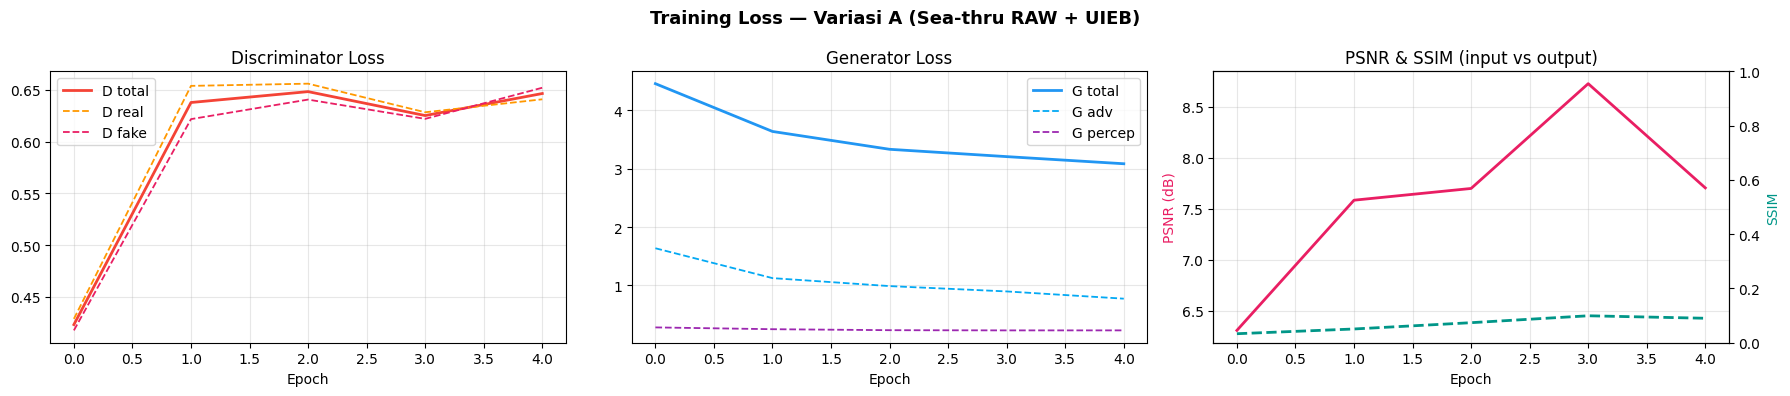

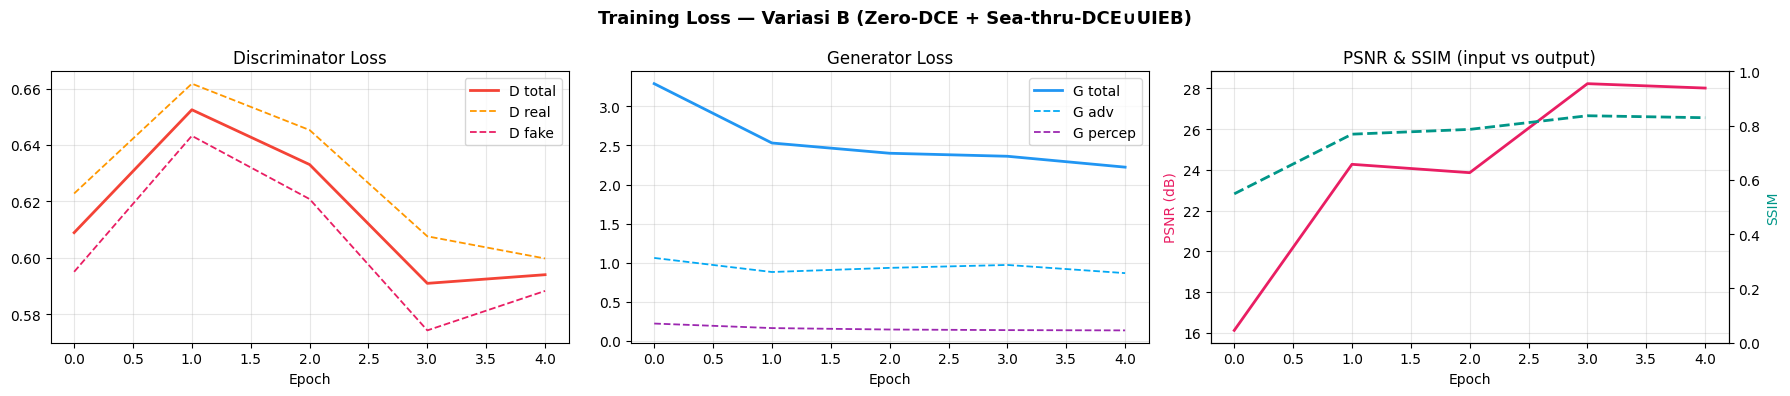

✅ Plot training loss tersimpan (A & B).


In [16]:
def plot_history(history, title, fname):
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    fig.suptitle(title, fontweight='bold', fontsize=13)

    axes[0].plot(history['loss_D'],      label='D total', color='#F44336', lw=2)
    axes[0].plot(history['loss_D_real'], '--', label='D real', color='#FF9800', lw=1.3)
    axes[0].plot(history['loss_D_fake'], '--', label='D fake', color='#E91E63', lw=1.3)
    axes[0].set_title('Discriminator Loss'); axes[0].set_xlabel('Epoch')
    axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(history['loss_G'],        label='G total',  color='#2196F3', lw=2)
    axes[1].plot(history['loss_G_adv'],    '--', label='G adv',    color='#03A9F4', lw=1.3)
    axes[1].plot(history['loss_G_percep'], '--', label='G percep', color='#9C27B0', lw=1.3)
    axes[1].set_title('Generator Loss'); axes[1].set_xlabel('Epoch')
    axes[1].legend(); axes[1].grid(alpha=0.3)

    ax3 = axes[2]; ax3b = ax3.twinx()
    ax3.plot(history['psnr'],  color='#E91E63', lw=2, label='PSNR (dB)')
    ax3b.plot(history['ssim'], '--', color='#009688', lw=2, label='SSIM')
    ax3.set_ylabel('PSNR (dB)', color='#E91E63'); ax3b.set_ylabel('SSIM', color='#009688')
    ax3b.set_ylim(0, 1)
    ax3.set_title('PSNR & SSIM (input vs output)'); ax3.set_xlabel('Epoch'); ax3.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(Path(MODEL_OUTPUT) / fname, dpi=130, bbox_inches='tight')
    plt.show(); plt.close()

plot_history(history_A, 'Training Loss — Variasi A (Sea-thru RAW + UIEB)',          'loss_A.png')
plot_history(history_B, 'Training Loss — Variasi B (Zero-DCE + Sea-thru-DCE∪UIEB)', 'loss_B.png')
print('✅ Plot training loss tersimpan (A & B).')


## Evaluasi - PNSR & SSIM 

In [17]:
# PSNR & SSIM sudah didefinisikan di cell sebelumnya (cell MobileNetV2).
# Cell ini hanya konfirmasi.
print('✅ calculate_psnr dan calculate_ssim sudah tersedia.')


✅ calculate_psnr dan calculate_ssim sudah tersedia.


## 📊 9. Evaluasi — UCIQE & NIQE

In [18]:
import cv2
from scipy.ndimage import uniform_filter

# ── UCIQE ─────────────────────────────────────────────────────────
def compute_uciqe(img_np):
    """img_np: [H,W,3] float [0,1]. Lebih tinggi lebih baik."""
    img_u8  = (np.clip(img_np,0,1)*255).astype(np.uint8)
    lab     = cv2.cvtColor(img_u8, cv2.COLOR_RGB2LAB).astype(np.float64)
    L = lab[:,:,0]/100.0; a = lab[:,:,1]; b = lab[:,:,2]
    chroma  = np.sqrt(a**2+b**2)
    sigma_c = chroma.std()
    con_l   = np.percentile(L,95) - np.percentile(L,5)
    mu_s    = (chroma/(L*100+1e-5)).mean()
    uciqe   = 0.4680*(sigma_c/127) + 0.2745*np.clip(con_l,0,1) + 0.2576*np.clip(mu_s/5,0,1)
    return round(float(np.clip(uciqe,0,1)), 4)

# ── NIQE ──────────────────────────────────────────────────────────
def compute_niqe(img_np, patch_size=96):
    """img_np: [H,W,3] float [0,1]. Lebih rendah lebih baik."""
    gray = np.mean(img_np,axis=2)
    g255 = np.clip(gray,0,1)*255.0
    mu   = uniform_filter(g255, size=7)
    var  = np.abs(uniform_filter(g255**2,size=7) - mu**2)
    mscn = (g255-mu)/(np.sqrt(var)+1)
    sigma = np.sqrt(var)
    H,W  = mscn.shape
    feats = []
    for i in range(0,H-patch_size+1,patch_size//2):
        for j in range(0,W-patch_size+1,patch_size//2):
            p = mscn[i:i+patch_size,j:j+patch_size].flatten()
            if len(p)==0: continue
            m2 = float(np.var(p)+1e-10)
            feats.append([p.mean(), m2,
                          float(np.mean((p-p.mean())**4)/(m2**2+1e-10)),
                          float(np.mean((p-p.mean())**3)/(m2**1.5+1e-10))])
    if not feats: return float('nan')
    feats = np.array(feats)
    mu_nat = np.array([0.0, 1.0, 3.0, 0.0])
    mu_t   = feats.mean(0)
    cov_t  = np.cov(feats.T)+np.eye(4)*1e-6
    try:
        diff = mu_t - mu_nat
        niqe = float(np.sqrt(max(diff @ np.linalg.inv(cov_t) @ diff, 0)))
    except: niqe = float('nan')
    return round(niqe, 4)

print('✅ Fungsi UCIQE & NIQE siap.')
print('   UCIQE ↑ : color balance, saturation, contrast (khusus underwater)')
print('   NIQE  ↓ : naturalness gambar (no-reference)')


✅ Fungsi UCIQE & NIQE siap.
   UCIQE ↑ : color balance, saturation, contrast (khusus underwater)
   NIQE  ↓ : naturalness gambar (no-reference)


In [19]:
import torchvision.transforms as T

G_A.eval(); G_B.eval(); dce_model.eval()

_tf_01 = T.Compose([T.Resize((256,256)), T.ToTensor()])
_tf_11 = T.Compose([T.Resize((256,256)), T.ToTensor(),
                    T.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])])

def _to_np_01(t): return np.clip(t.squeeze(0).cpu().permute(1,2,0).numpy(), 0, 1)
def _to_np_11(t): return np.clip(t.squeeze(0).cpu().permute(1,2,0).numpy()*0.5+0.5, 0, 1)

# Urutan kolom perbandingan: Input | Zero-DCE | Variasi A | Variasi B
MODEL_ORDER = ['Input', 'Zero-DCE',
               'FUnIE-GAN (A: Sea-thru+UIEB)',
               'Zero-DCE+FUnIE-GAN (B: gabungan)']

@torch.no_grad()
def enhance(image_path):
    """Hasilkan 4 keluaran: Input, Zero-DCE, Variasi A, Variasi B."""
    img = Image.open(image_path).convert('RGB')
    t01 = _tf_01(img).unsqueeze(0).to(DEVICE)   # [0,1]
    t11 = _tf_11(img).unsqueeze(0).to(DEVICE)   # [-1,1]

    res = {'Input': _to_np_01(t01)}

    dce_out, _ = dce_model(t01)                  # Zero-DCE only
    res['Zero-DCE'] = _to_np_01(dce_out)

    res[MODEL_ORDER[2]] = _to_np_11(G_A(t11))    # Variasi A: Sea-thru raw → G_A

    dce_11 = dce_out * 2 - 1                      # Variasi B: Zero-DCE → G_B
    res[MODEL_ORDER[3]] = _to_np_11(G_B(dce_11))
    return res


def metrics_vs_input(res):
    """PSNR & SSIM tiap output terhadap Input (unpaired self-reference)."""
    inp = res['Input'].astype(np.float32)
    out = {}
    for name in MODEL_ORDER:
        img = res[name].astype(np.float32)
        if name == 'Input':
            out[name] = (float('inf'), 1.0); continue
        mse  = np.mean((inp - img) ** 2)
        psnr = 10 * np.log10(1.0 / (mse + 1e-10))
        a = torch.tensor(inp).permute(2,0,1).unsqueeze(0)
        b = torch.tensor(img).permute(2,0,1).unsqueeze(0)
        s = ssim_fn(a, b, data_range=1.0, size_average=True).item()
        out[name] = (round(float(psnr), 3), round(float(s), 4))
    return out


# ── Sampel uji ─────────────────────────────────────────────────────
SAMPLE_PATHS = [
    '/kaggle/input/datasets/colorlabeilat/seathru-dataset/D1/D1/linearPNG/T_S02951.png',
    '/kaggle/input/datasets/colorlabeilat/seathru-dataset/D3/D3/linearPNG/T_S04860.png',
    '/kaggle/input/datasets/colorlabeilat/seathru-dataset/D5/D5/linearPNG/LFT_3374.png',
]
SAMPLE_PATHS = [p for p in SAMPLE_PATHS if Path(p).exists()]
if len(SAMPLE_PATHS) < 3 and len(seathru_paths) >= 3:
    extra = [str(p) for p in seathru_paths if str(p) not in SAMPLE_PATHS]
    SAMPLE_PATHS += extra[:3 - len(SAMPLE_PATHS)]

print(f"  {'Image':<22} {'Model':<34} {'UCIQE':>7} {'NIQE':>7} {'PSNR':>8} {'SSIM':>7}")
print('  ' + '-' * 90)

all_res, all_metrics = {}, {}
for sp in SAMPLE_PATHS:
    res = enhance(sp); all_res[sp] = res
    mvi = metrics_vs_input(res); all_metrics[sp] = mvi
    for name in MODEL_ORDER:
        u = compute_uciqe(res[name]); n = compute_niqe(res[name])
        ps, ss = mvi[name]
        ps_s = '   —   ' if ps == float('inf') else f'{ps:8.3f}'
        print(f"  {Path(sp).name:<22} {name:<34} {u:>7.4f} {n:>7.4f} {ps_s:>8} {ss:>7.4f}")
    print()


  Image                  Model                                UCIQE    NIQE     PSNR    SSIM
  ------------------------------------------------------------------------------------------
  T_S02951.png           Input                               0.4852  9.9069     —     1.0000
  T_S02951.png           Zero-DCE                            0.3298 25.0093   11.628  0.4622
  T_S02951.png           FUnIE-GAN (A: Sea-thru+UIEB)        0.3644 21.0083    3.913  0.1421
  T_S02951.png           Zero-DCE+FUnIE-GAN (B: gabungan)    0.3533 26.8563    6.355  0.2369

  T_S04860.png           Input                               0.3576 16.7082     —     1.0000
  T_S04860.png           Zero-DCE                            0.5557 14.8423   13.352  0.2722
  T_S04860.png           FUnIE-GAN (A: Sea-thru+UIEB)        0.5170  8.1346    7.973  0.0854
  T_S04860.png           Zero-DCE+FUnIE-GAN (B: gabungan)    0.4951 23.0282    5.832  0.0908

  LFT_3374.png           Input                               0.3176 

💾 /kaggle/working/model_output/comparison_results.png


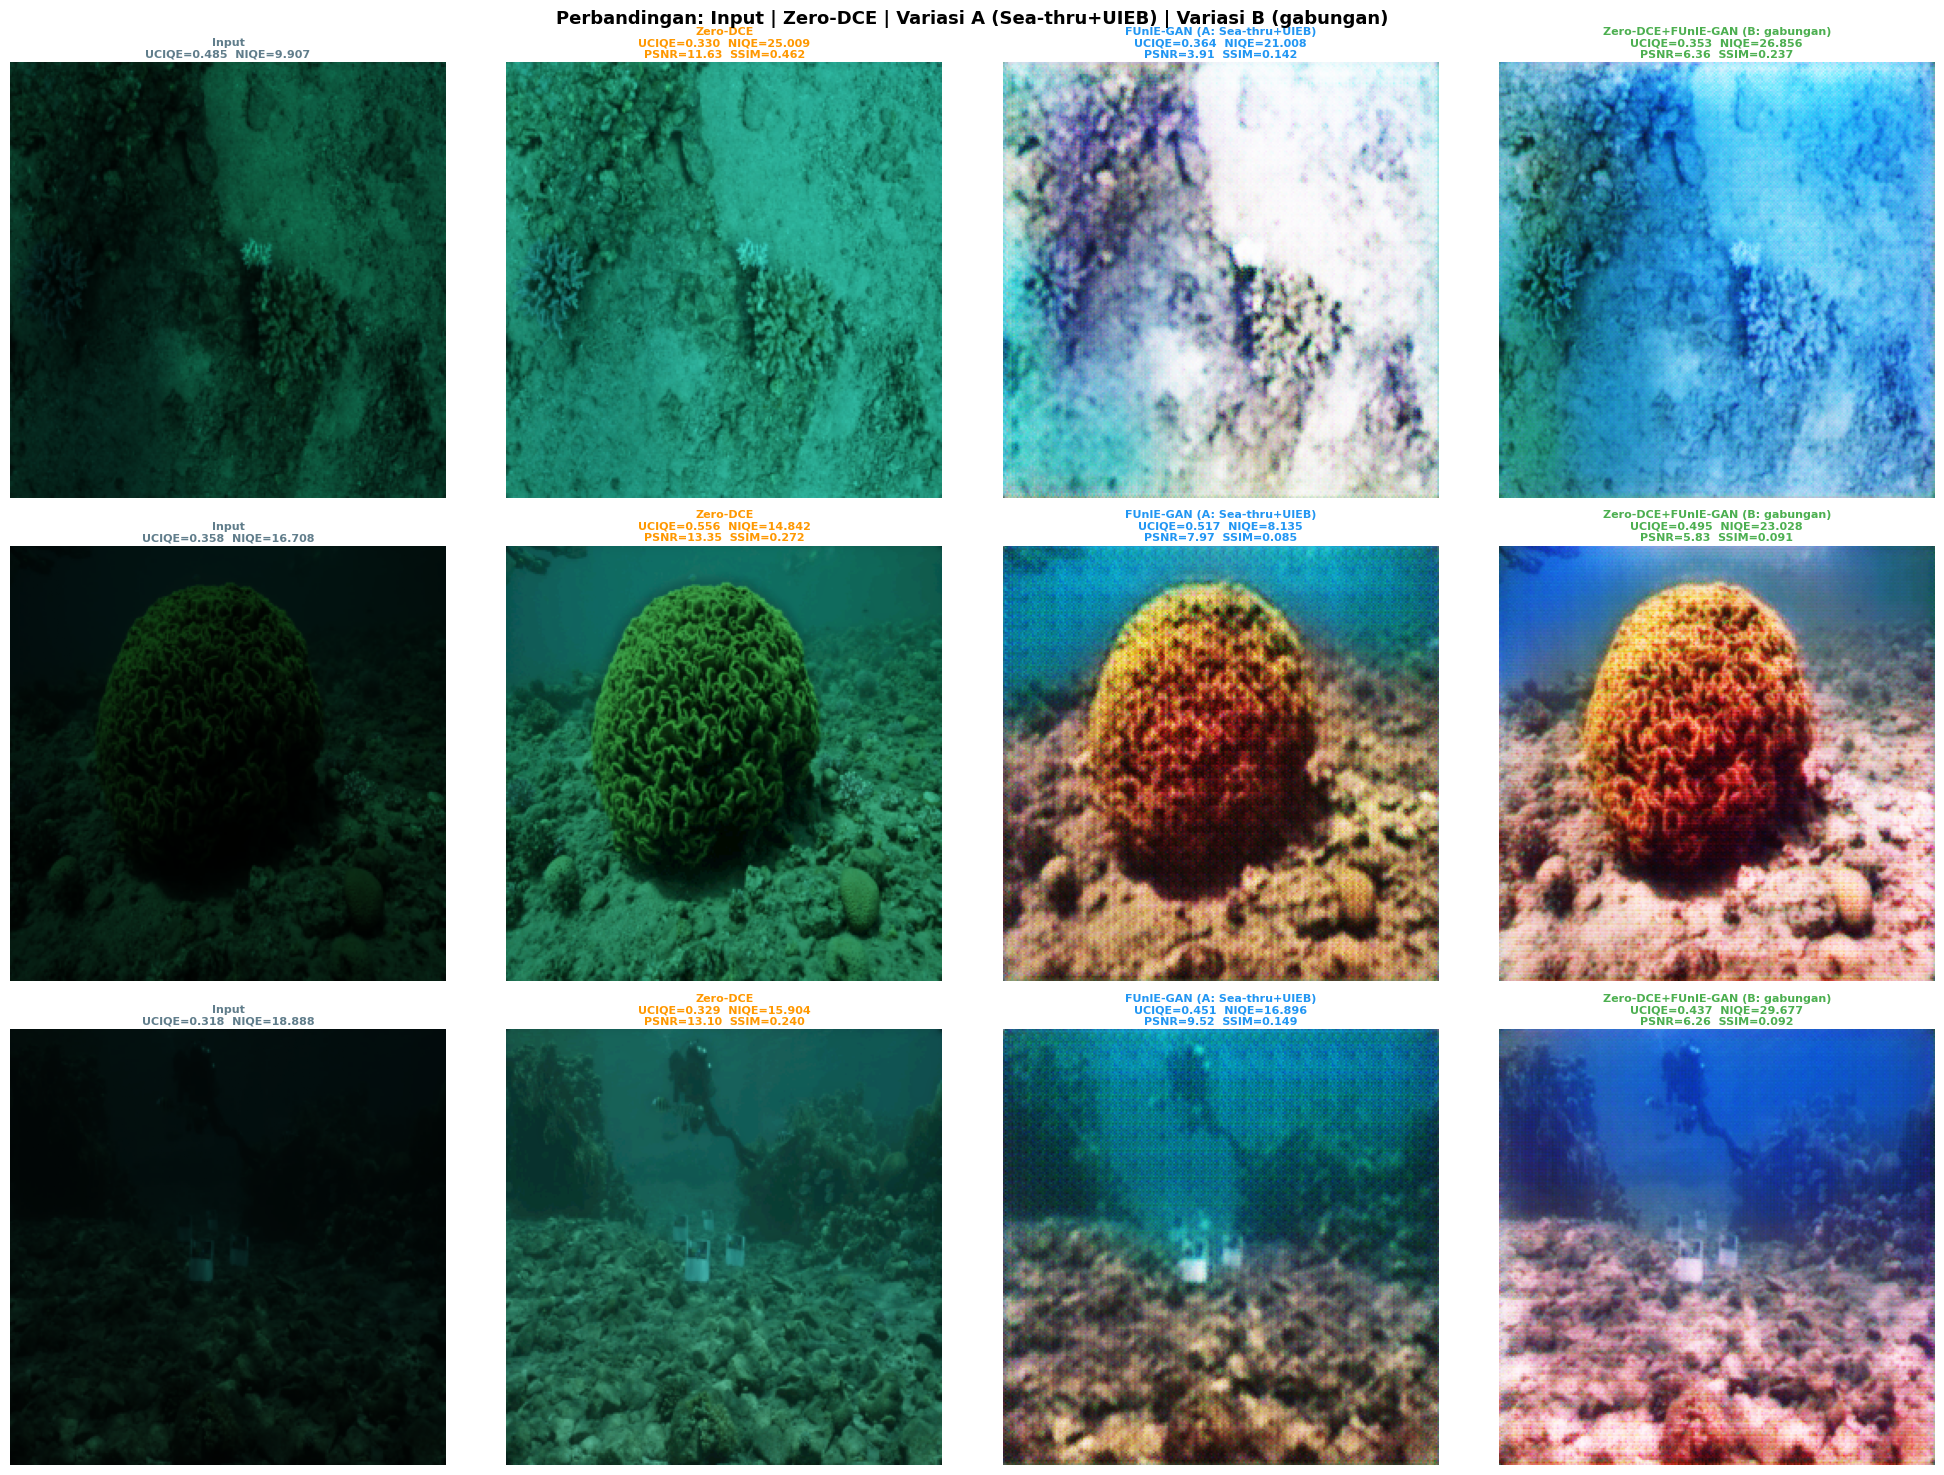

In [20]:
def show_results(all_res, all_metrics=None, save=True):
    """Grid: 1 baris per gambar, 4 kolom (Input | Zero-DCE | Variasi A | Variasi B)."""
    COLORS = ['#607D8B', '#FF9800', '#2196F3', '#4CAF50']
    n = len(all_res)
    if n == 0:
        print('Tidak ada gambar.'); return

    fig, axes = plt.subplots(n, 4, figsize=(20, 5*n))
    if n == 1: axes = [axes]

    for ax_row, (sp, res) in zip(axes, all_res.items()):
        for ax, name, color in zip(ax_row, MODEL_ORDER, COLORS):
            img = res.get(name, np.zeros((256,256,3)))
            u = compute_uciqe(img); ni = compute_niqe(img)
            extra = ''
            if all_metrics and sp in all_metrics:
                ps, ss = all_metrics[sp][name]
                if ps != float('inf'):
                    extra = f'\nPSNR={ps:.2f}  SSIM={ss:.3f}'
            ax.imshow(np.clip(img, 0, 1))
            ax.set_title(f'{name}\nUCIQE={u:.3f}  NIQE={ni:.3f}{extra}',
                         fontsize=8, fontweight='bold', color=color, pad=3)
            ax.axis('off')
            for s in ax.spines.values():
                s.set_visible(True); s.set_edgecolor(color); s.set_linewidth(2)
        ax_row[0].set_ylabel(Path(sp).name, fontsize=7, rotation=0, labelpad=85, va='center')

    fig.suptitle('Perbandingan: Input | Zero-DCE | Variasi A (Sea-thru+UIEB) | Variasi B (gabungan)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    if save:
        out = Path(MODEL_OUTPUT) / 'comparison_results.png'
        plt.savefig(out, dpi=130, bbox_inches='tight')
        print(f'💾 {out}')
    plt.show(); plt.close()

show_results(all_res, all_metrics)


## 🏆 10. Kesimpulan

**Kontribusi yang diklaim:**
1. **Zero-DCE sebagai preprocessor** memperbaiki kondisi cahaya Sea-thru sebelum masuk GAN.
2. **Dataset gabungan** (Sea-thru Light-Corrected + UIEB) membuat Discriminator lebih robust terhadap variasi domain underwater.
3. **UCIQE ↑ & NIQE ↓** pada Variasi B = bukti output Generator lebih natural & seimbang dibanding Baseline (Variasi A).

> Catatan unpaired: UCIQE & NIQE (no-reference) adalah metrik utama; PSNR & SSIM hanya mengukur besar perubahan Input→Output.



════════════════════════════════════════════════════════════
  KESIMPULAN EVALUASI — Variasi A vs Variasi B
════════════════════════════════════════════════════════════

  Model                                UCIQE ↑    NIQE ↓      PSNR     SSIM
  ────────────────────────────────────────────────────────────────────────
  Input                                 0.3868   15.1677       —        —  
  Zero-DCE                              0.4048   18.5853    12.694   0.3249
  FUnIE-GAN (A: Sea-thru+UIEB)          0.4440   15.3463     7.135   0.1254
  Zero-DCE+FUnIE-GAN (B: gabungan)      0.4284   26.5207     6.148   0.1400
  ────────────────────────────────────────────────────────────────────────
  Catatan: PSNR/SSIM dihitung Input-vs-Output (ukuran perubahan G, bukan kualitas absolut).

  UCIQE ↑ Ranking:
  🥇  FUnIE-GAN (A: Sea-thru+UIEB)       0.4440
  🥈  Zero-DCE+FUnIE-GAN (B: gabungan)   0.4284
  🥉  Zero-DCE                           0.4048
  4️⃣  Input                              0.38

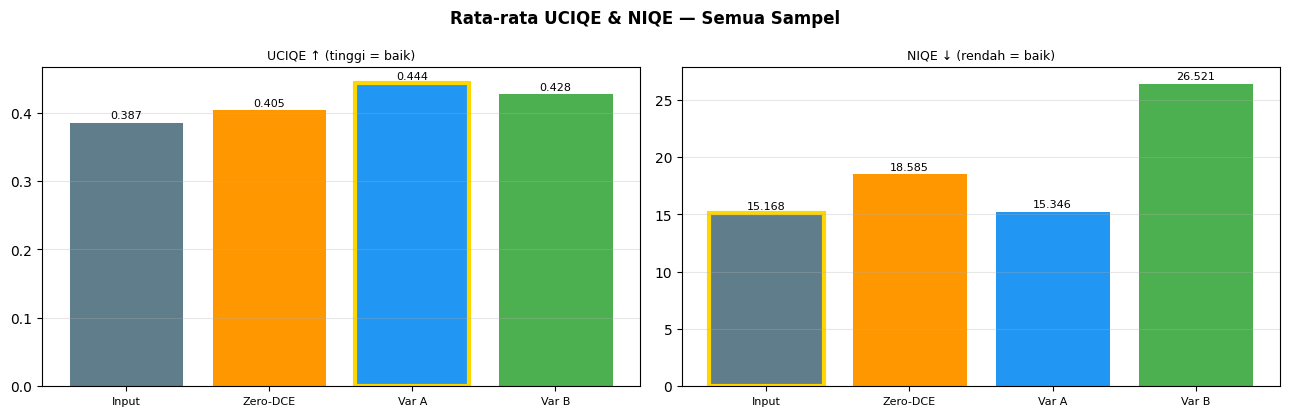

In [21]:
def print_summary(all_res, all_metrics):
    print_section('KESIMPULAN EVALUASI — Variasi A vs Variasi B')

    # ── Agregasi metrik ──
    agg = {m: {'UCIQE':[], 'NIQE':[], 'PSNR':[], 'SSIM':[]} for m in MODEL_ORDER}
    for sp, res in all_res.items():
        for name in MODEL_ORDER:
            if name not in res: continue
            agg[name]['UCIQE'].append(compute_uciqe(res[name]))
            agg[name]['NIQE'].append(compute_niqe(res[name]))
            ps, ss = all_metrics[sp][name]
            if ps != float('inf'):
                agg[name]['PSNR'].append(ps); agg[name]['SSIM'].append(ss)

    def mean(x): return round(float(np.nanmean(x)), 4) if len(x) else float('nan')
    avg = {m: {k: mean(agg[m][k]) for k in agg[m]} for m in MODEL_ORDER}

    # ── Tabel ──
    print(f"\n  {'Model':<34} {'UCIQE ↑':>9} {'NIQE ↓':>9} {'PSNR':>9} {'SSIM':>8}")
    print('  ' + '─' * 72)
    for name in MODEL_ORDER:
        a = avg[name]
        psnr_s = '  —  ' if name == 'Input' else f"{a['PSNR']:9.3f}"
        ssim_s = '  —  ' if name == 'Input' else f"{a['SSIM']:8.4f}"
        print(f"  {name:<34} {a['UCIQE']:>9.4f} {a['NIQE']:>9.4f} {psnr_s:>9} {ssim_s:>8}")
    print('  ' + '─' * 72)
    print('  Catatan: PSNR/SSIM dihitung Input-vs-Output (ukuran perubahan G, bukan kualitas absolut).')

    # ── Ranking (no-reference) ──
    ranked_u = sorted(MODEL_ORDER, key=lambda m: avg[m]['UCIQE'], reverse=True)
    ranked_n = sorted(MODEL_ORDER, key=lambda m: avg[m]['NIQE'])
    medals = ['🥇','🥈','🥉','4️⃣']
    print('\n  UCIQE ↑ Ranking:')
    for i, m in enumerate(ranked_u):
        print(f'  {medals[i]}  {m:<34} {avg[m]["UCIQE"]:.4f}')
    print('\n  NIQE ↓ Ranking:')
    for i, m in enumerate(ranked_n):
        print(f'  {medals[i]}  {m:<34} {avg[m]["NIQE"]:.4f}')

    # ── Perbandingan langsung A vs B ──
    A = MODEL_ORDER[2]; B = MODEL_ORDER[3]
    print('\n  ── A vs B (Proposed) ──')
    du = avg[B]['UCIQE'] - avg[A]['UCIQE']
    dn = avg[B]['NIQE']  - avg[A]['NIQE']
    print(f'  ΔUCIQE (B−A) : {du:+.4f}  ({"B lebih baik" if du > 0 else "A lebih baik"})')
    print(f'  ΔNIQE  (B−A) : {dn:+.4f}  ({"B lebih baik" if dn < 0 else "A lebih baik"})')
    print(f'\n  📌 Terbaik (UCIQE): {ranked_u[0]}')
    print(f'  📁 Output tersimpan di: {MODEL_OUTPUT}')

    # ── Bar chart ──
    COLORS = ['#607D8B', '#FF9800', '#2196F3', '#4CAF50']
    short  = ['Input', 'Zero-DCE', 'Var A', 'Var B']
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
    fig.suptitle('Rata-rata UCIQE & NIQE — Semua Sampel', fontsize=12, fontweight='bold')
    for ax, metric, title, best_fn in [
        (axes[0], 'UCIQE', 'UCIQE ↑ (tinggi = baik)', np.argmax),
        (axes[1], 'NIQE',  'NIQE ↓ (rendah = baik)',  np.argmin),
    ]:
        vals = [avg[m][metric] for m in MODEL_ORDER]
        bars = ax.bar(short, vals, color=COLORS, edgecolor='white', linewidth=0.7)
        ax.set_title(title, fontsize=9); ax.grid(axis='y', alpha=0.3)
        ax.tick_params(axis='x', labelsize=8)
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+max(vals)*0.01,
                    f'{val:.3f}', ha='center', fontsize=8)
        bars[int(best_fn(vals))].set_edgecolor('gold')
        bars[int(best_fn(vals))].set_linewidth(3)
    plt.tight_layout()
    out = Path(MODEL_OUTPUT) / 'summary_chart.png'
    plt.savefig(out, dpi=130, bbox_inches='tight')
    print(f'\n  💾 Chart: {out}')
    plt.show(); plt.close()


print_summary(all_res, all_metrics)
